In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/alextamboli/unsw-nb15/UNSW-NB15_c/The UNSW-NB15 description.pdf
/kaggle/input/datasets/alextamboli/unsw-nb15/UNSW-NB15_c/UNSW_NB15_testing-set.csv
/kaggle/input/datasets/alextamboli/unsw-nb15/UNSW-NB15_c/UNSW-NB15_1.csv
/kaggle/input/datasets/alextamboli/unsw-nb15/UNSW-NB15_c/UNSW_NB15_training-set.csv
/kaggle/input/datasets/alextamboli/unsw-nb15/UNSW-NB15_c/UNSW-NB15_LIST_EVENTS.csv
/kaggle/input/datasets/alextamboli/unsw-nb15/UNSW-NB15_c/UNSW-NB15_4.csv
/kaggle/input/datasets/alextamboli/unsw-nb15/UNSW-NB15_c/NUSW-NB15_GT.csv
/kaggle/input/datasets/alextamboli/unsw-nb15/UNSW-NB15_c/UNSW-NB15_3.csv
/kaggle/input/datasets/alextamboli/unsw-nb15/UNSW-NB15_c/UNSW-NB15_2.csv
/kaggle/input/datasets/alextamboli/unsw-nb15/UNSW-NB15_c/NUSW-NB15_features.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json, os, time, warnings, joblib
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.impute import SimpleImputer

print(f'TensorFlow : {tf.__version__}')
print(f'GPU devices: {tf.config.list_physical_devices("GPU")}')
os.makedirs('models', exist_ok=True)
PAL = ['#4f7cff','#22c55e','#f59e0b','#ef4444','#8b5cf6','#06b6d4','#ec4899','#14b8a6']
RANDOM = 42
tf.random.set_seed(RANDOM)
np.random.seed(RANDOM)
print('Imports ready.')

2026-05-02 11:01:14.758445: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777719674.943770      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777719674.994285      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777719675.422953      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777719675.422997      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777719675.423000      23 computation_placer.cc:177] computation placer alr

TensorFlow : 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Imports ready.


In [3]:
TRAIN_PATH = '/kaggle/input/datasets/alextamboli/unsw-nb15/UNSW-NB15_c/UNSW_NB15_testing-set.csv'
TEST_PATH  = '/kaggle/input/datasets/alextamboli/unsw-nb15/UNSW-NB15_c/UNSW_NB15_training-set.csv'

df_train = pd.read_csv(TRAIN_PATH, low_memory=False)
df_test  = pd.read_csv(TEST_PATH,  low_memory=False)

print(f'Train shape : {df_train.shape}')
print(f'Test  shape : {df_test.shape}')
print(f'Columns     : {list(df_train.columns)}')
print(f'\nTrain attack_cat:\n{df_train["attack_cat"].value_counts()}')
print(f'\nTest attack_cat:\n{df_test["attack_cat"].value_counts()}')

Train shape : (175341, 45)
Test  shape : (82332, 45)
Columns     : ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

Train attack_cat:
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

Test attack_cat:
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            

In [4]:
FEATURE_COLS = [
    'dur','spkts','dpkts','sbytes','dbytes','rate',
    'sttl','dttl','sload','dload','sloss','dloss',
    'sinpkt','dinpkt','sjit','djit',
    'swin','stcpb','dtcpb','dwin',
    'tcprtt','synack','ackdat',
    'smean','dmean','trans_depth','response_body_len',
    'ct_srv_src','ct_state_ttl','ct_dst_ltm',
    'ct_src_dport_ltm','ct_dst_sport_ltm','ct_dst_src_ltm',
    'is_ftp_login','ct_ftp_cmd','ct_flw_http_mthd',
    'ct_src_ltm','ct_srv_dst','is_sm_ips_ports',
]
CAT_COLS  = ['proto','service','state']
LABEL_COL = 'attack_cat'

def preprocess(df, cat_encoders=None, fit=True):
    df = df.copy()
    encoders = {} if fit else cat_encoders
    for col in CAT_COLS:
        if col not in df.columns: continue
        if fit:
            enc = LabelEncoder()
            df[col] = enc.fit_transform(df[col].astype(str).fillna('unknown'))
            encoders[col] = enc
        else:
            enc = encoders[col]
            known = set(enc.classes_)
            df[col] = df[col].astype(str).apply(
                lambda x: x if x in known else enc.classes_[0])
            df[col] = enc.transform(df[col])
    all_feats = FEATURE_COLS + [c for c in CAT_COLS if c in df.columns]
    all_feats = [f for f in all_feats if f in df.columns]
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    return df, all_feats, encoders

df_train, ALL_FEATS, CAT_ENCODERS = preprocess(df_train, fit=True)
df_test,  ALL_FEATS, _            = preprocess(df_test, cat_encoders=CAT_ENCODERS, fit=False)

imputer = SimpleImputer(strategy='median')
df_train[ALL_FEATS] = imputer.fit_transform(df_train[ALL_FEATS])
df_test[ALL_FEATS]  = imputer.transform(df_test[ALL_FEATS])

df_train['label_binary'] = (df_train['label'] == 1).astype(int)
df_test['label_binary']  = (df_test['label']  == 1).astype(int)

df_train['attack_cat'] = df_train['attack_cat'].fillna('Normal').str.strip()
df_test['attack_cat']  = df_test['attack_cat'].fillna('Normal').str.strip()

le = LabelEncoder()
all_cats = pd.concat([df_train['attack_cat'], df_test['attack_cat']]).unique()
le.fit(all_cats)
df_train['label_multi'] = le.transform(df_train['attack_cat'])
df_test['label_multi']  = le.transform(df_test['attack_cat'])

CLASS_NAMES = list(le.classes_)
N_CLASSES   = len(CLASS_NAMES)
FEAT        = len(ALL_FEATS)

print(f'Attack categories ({N_CLASSES}): {CLASS_NAMES}')
print(f'Features: {FEAT}')

joblib.dump(imputer,      'models/v2_imputer.pkl')
joblib.dump(CAT_ENCODERS, 'models/v2_cat_encoders.pkl')
with open('models/v2_feature_names.json','w') as f: json.dump(ALL_FEATS, f)
with open('models/v2_label_classes.json','w') as f: json.dump(CLASS_NAMES, f)
print('Metadata saved.')

Attack categories (10): ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']
Features: 42
Metadata saved.


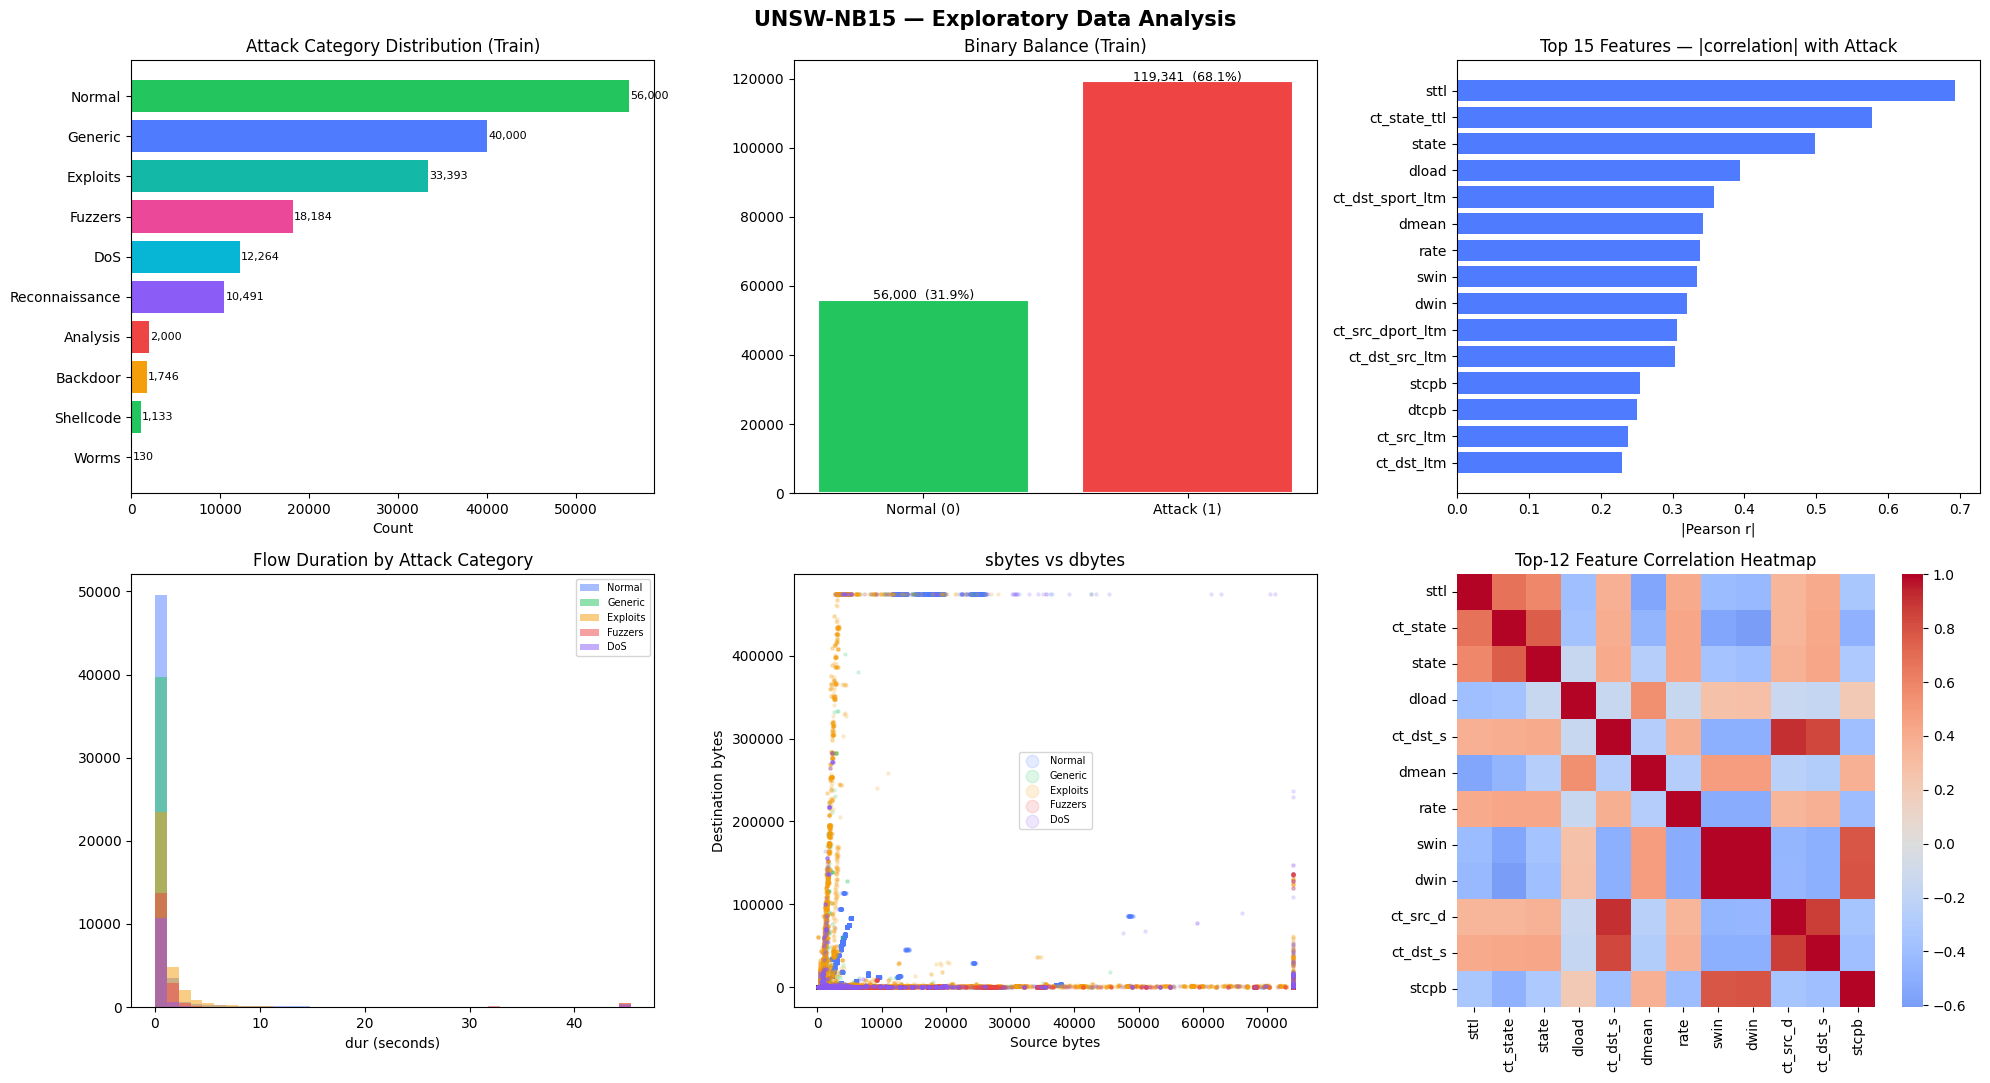

EDA saved.


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('UNSW-NB15 — Exploratory Data Analysis', fontsize=15, fontweight='bold')

vc = df_train['attack_cat'].value_counts()
axes[0,0].barh(vc.index[::-1], vc.values[::-1],
               color=[PAL[i % len(PAL)] for i in range(len(vc))])
axes[0,0].set_title('Attack Category Distribution (Train)')
axes[0,0].set_xlabel('Count')
for i, v in enumerate(vc.values[::-1]):
    axes[0,0].text(v + 100, i, f'{v:,}', va='center', fontsize=8)

bin_vc = df_train['label_binary'].value_counts().sort_index()
axes[0,1].bar(['Normal (0)', 'Attack (1)'], bin_vc.values,
               color=[PAL[1], PAL[3]], edgecolor='white', linewidth=1.5)
axes[0,1].set_title('Binary Balance (Train)')
for i, v in enumerate(bin_vc.values):
    pct = v / len(df_train) * 100
    axes[0,1].text(i, v + 100, f'{v:,}  ({pct:.1f}%)', ha='center', fontsize=9)

corr = df_train[ALL_FEATS].corrwith(df_train['label_binary']).abs().sort_values(ascending=False)
top15 = corr.head(15)
axes[0,2].barh(top15.index[::-1], top15.values[::-1], color=PAL[0])
axes[0,2].set_title('Top 15 Features — |correlation| with Attack')
axes[0,2].set_xlabel('|Pearson r|')

top5 = df_train['attack_cat'].value_counts().nlargest(5).index
for cls, col in zip(top5, PAL):
    mask = df_train['attack_cat'] == cls
    data = df_train.loc[mask, 'dur'].clip(0, df_train['dur'].quantile(0.99))
    axes[1,0].hist(data, bins=40, alpha=0.5, label=cls, color=col)
axes[1,0].set_title('Flow Duration by Attack Category')
axes[1,0].set_xlabel('dur (seconds)')
axes[1,0].legend(fontsize=7)

for cls, col in zip(top5, PAL):
    mask = df_train['attack_cat'] == cls
    axes[1,1].scatter(
        df_train.loc[mask,'sbytes'].clip(0, df_train['sbytes'].quantile(0.99)),
        df_train.loc[mask,'dbytes'].clip(0, df_train['dbytes'].quantile(0.99)),
        alpha=0.15, s=5, label=cls, color=col)
axes[1,1].set_title('sbytes vs dbytes')
axes[1,1].set_xlabel('Source bytes')
axes[1,1].set_ylabel('Destination bytes')
axes[1,1].legend(markerscale=4, fontsize=7)

top12_feats = corr.head(12).index.tolist()
sns.heatmap(df_train[top12_feats].corr(), ax=axes[1,2], cmap='coolwarm',
            center=0, annot=False,
            xticklabels=[f[:8] for f in top12_feats],
            yticklabels=[f[:8] for f in top12_feats])
axes[1,2].set_title('Top-12 Feature Correlation Heatmap')

plt.tight_layout()
plt.savefig('models/eda_unsw.png', dpi=120, bbox_inches='tight')
plt.show()
print('EDA saved.')

In [6]:
scaler = RobustScaler()
X_tr_flat = scaler.fit_transform(df_train[ALL_FEATS].values)
X_te_flat = scaler.transform(df_test[ALL_FEATS].values)

y_tr_b = df_train['label_binary'].values
y_te_b = df_test['label_binary'].values
y_tr_m = df_train['label_multi'].values
y_te_m = df_test['label_multi'].values

joblib.dump(scaler, 'models/v2_scaler.pkl')
print(f'Train flat: {X_tr_flat.shape}  Test flat: {X_te_flat.shape}')

T = 20   # timesteps per sequence

def make_sequences(X_flat, y, T=20, step=5):
    seqs, labels = [], []
    for i in range(0, len(X_flat) - T, step):
        seqs.append(X_flat[i:i+T])
        labels.append(y[i+T-1])
    return np.array(seqs, dtype=np.float32), np.array(labels)

print('Building sequences...')
X_seq_tr, y_seq_tr_b = make_sequences(X_tr_flat, y_tr_b, T=T, step=5)
X_seq_te, y_seq_te_b = make_sequences(X_te_flat, y_te_b, T=T, step=5)
_,        y_seq_tr_m = make_sequences(X_tr_flat, y_tr_m, T=T, step=5)
_,        y_seq_te_m = make_sequences(X_te_flat, y_te_m, T=T, step=5)

FEAT = X_seq_tr.shape[2]
print(f'Train sequences: {X_seq_tr.shape}')
print(f'Test  sequences: {X_seq_te.shape}')
print(f'Sequence shape : (samples, T={T}, features={FEAT})')
print(f'Binary balance : {dict(zip(*np.unique(y_seq_tr_b, return_counts=True)))}')

Train flat: (175341, 42)  Test flat: (82332, 42)
Building sequences...
Train sequences: (35065, 20, 42)
Test  sequences: (16463, 20, 42)
Sequence shape : (samples, T=20, features=42)
Binary balance : {np.int64(0): np.int64(11209), np.int64(1): np.int64(23856)}


I0000 00:00:1777719711.905520      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777719711.911327      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "protector_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20, 42)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 20, 64)         │         8,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 20, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 10, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,689 (260.50 KB)

 Trainable params: 66,305 (259.00 KB)

...

Epoch 1/40


I0000 00:00:1777719715.879962      75 service.cc:152] XLA service 0x7854f4012a50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777719715.879991      75 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777719715.879994      75 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777719716.412122      75 cuda_dnn.cc:529] Loaded cuDNN version 91002


 28/117 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - AUC: 0.8313 - accuracy: 0.7718 - loss: 0.5179

I0000 00:00:1777719719.801392      75 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


117/117 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - AUC: 0.9025 - accuracy: 0.8597 - loss: 0.3532 - val_AUC: 0.0000e+00 - val_accuracy: 0.9987 - val_loss: 0.1985 - learning_rate: 0.0010
Epoch 2/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.9761 - accuracy: 0.9357 - loss: 0.1676 - val_AUC: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0259 - learning_rate: 0.0010
Epoch 3/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.9809 - accuracy: 0.9439 - loss: 0.1489 - val_AUC: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0070 - learning_rate: 0.0010
Epoch 4/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.9838 - accuracy: 0.9493 - loss: 0.1352 - val_AUC: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0017 - learning_rate: 0.0010
Epoch 5/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.9848 - accuracy: 0.9514 - loss: 0.1301 - val_AUC: 0.0000e+00 - val_accuracy: 0.9996 - val_loss: 0.0046 - learning_rate: 0.0010
Epoch 6/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.9866 - a

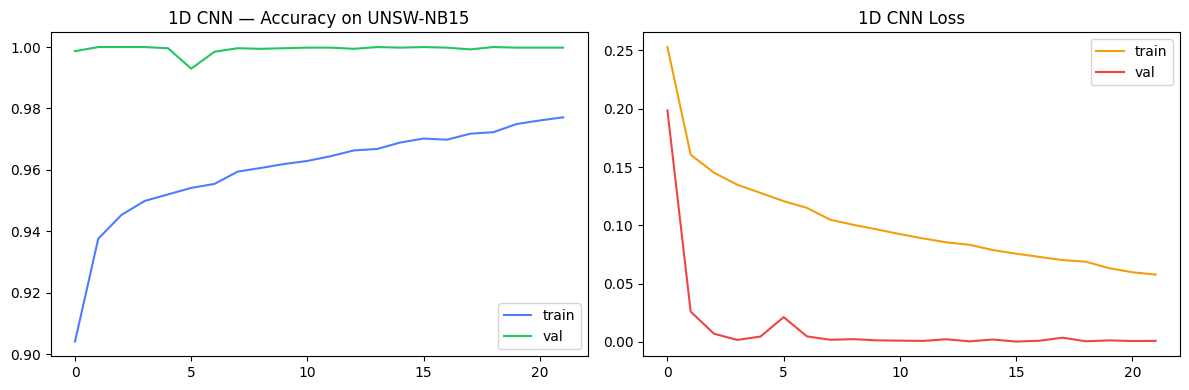

CNN saved.


In [7]:
def build_cnn(T, FEAT, n_cls=1):
    inp = keras.Input(shape=(T, FEAT))
    x   = layers.Conv1D(64, 3, activation='relu', padding='same')(inp)
    x   = layers.BatchNormalization()(x)
    x   = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.MaxPooling1D(2)(x)
    x   = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
    x   = layers.GlobalAveragePooling1D()(x)
    x   = layers.Dense(128, activation='relu')(x)
    x   = layers.Dropout(0.3)(x)
    if n_cls == 1:
        out   = layers.Dense(1, activation='sigmoid')(x)
        model = Model(inp, out, name='protector_cnn')
        model.compile(optimizer='adam', loss='binary_crossentropy',
                      metrics=['accuracy', 'AUC'])
    else:
        out   = layers.Dense(n_cls, activation='softmax')(x)
        model = Model(inp, out, name='protector_cnn_multi')
        model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
    return model

cbs = [EarlyStopping(patience=6, restore_best_weights=True),
       ReduceLROnPlateau(factor=0.5, patience=3)]

cnn_b = build_cnn(T, FEAT, n_cls=1)
cnn_b.summary()
h_cnn = cnn_b.fit(X_seq_tr, y_seq_tr_b, epochs=40, batch_size=256,
                   validation_split=0.15, callbacks=cbs, verbose=1)
cnn_acc = cnn_b.evaluate(X_seq_te, y_seq_te_b, verbose=0)[1]
cnn_b.save('models/v2_cnn.keras')

cnn_m = build_cnn(T, FEAT, n_cls=N_CLASSES)
cnn_m.fit(X_seq_tr, y_seq_tr_m, epochs=40, batch_size=256,
          validation_split=0.15,
          callbacks=[EarlyStopping(patience=6, restore_best_weights=True)], verbose=0)
cnn_m_acc = cnn_m.evaluate(X_seq_te, y_seq_te_m, verbose=0)[1]
cnn_m.save('models/v2_cnn_multi.keras')

print(f'1D CNN Binary    | Acc: {cnn_acc:.4f}')
print(f'1D CNN Multi-cls | Acc: {cnn_m_acc:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(h_cnn.history['accuracy'],     label='train', color=PAL[0])
axes[0].plot(h_cnn.history['val_accuracy'],  label='val',   color=PAL[1])
axes[0].set_title('1D CNN — Accuracy on UNSW-NB15'); axes[0].legend()
axes[1].plot(h_cnn.history['loss'],     label='train', color=PAL[2])
axes[1].plot(h_cnn.history['val_loss'],  label='val',   color=PAL[3])
axes[1].set_title('1D CNN Loss'); axes[1].legend()
plt.tight_layout(); plt.savefig('models/cnn_training.png', dpi=120); plt.show()
print('CNN saved.')

In [8]:
def build_lstm(T, FEAT, n_cls=1, bidirectional=False):
    inp = keras.Input(shape=(T, FEAT))
    if bidirectional:
        x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(inp)
        x = layers.Bidirectional(layers.LSTM(64))(x)
    else:
        x = layers.LSTM(128, return_sequences=True)(inp)
        x = layers.LSTM(64)(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(64, activation='relu')(x)
    x   = layers.Dropout(0.2)(x)
    if n_cls == 1:
        out   = layers.Dense(1, activation='sigmoid')(x)
        model = Model(inp, out)
        model.compile(optimizer=keras.optimizers.Adam(1e-3),
                      loss='binary_crossentropy', metrics=['accuracy', 'AUC'])
    else:
        out   = layers.Dense(n_cls, activation='softmax')(x)
        model = Model(inp, out)
        model.compile(optimizer=keras.optimizers.Adam(1e-3),
                      loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

cb_es = EarlyStopping(patience=6, restore_best_weights=True)

# Standard LSTM — binary
lstm_b = build_lstm(T, FEAT, n_cls=1, bidirectional=False)
lstm_b.fit(X_seq_tr, y_seq_tr_b, epochs=40, batch_size=256,
           validation_split=0.15, callbacks=[cb_es], verbose=0)
lstm_acc = lstm_b.evaluate(X_seq_te, y_seq_te_b, verbose=0)[1]
lstm_b.save('models/v2_lstm.keras')
print(f'LSTM Binary       | Acc: {lstm_acc:.4f}')

# Standard LSTM — multi-class
lstm_m = build_lstm(T, FEAT, n_cls=N_CLASSES, bidirectional=False)
lstm_m.fit(X_seq_tr, y_seq_tr_m, epochs=40, batch_size=256,
           validation_split=0.15, callbacks=[cb_es], verbose=0)
lstm_m_acc = lstm_m.evaluate(X_seq_te, y_seq_te_m, verbose=0)[1]
lstm_m.save('models/v2_lstm_multi.keras')
print(f'LSTM Multi-cls    | Acc: {lstm_m_acc:.4f}')

# Bidirectional LSTM — binary
bilstm_b = build_lstm(T, FEAT, n_cls=1, bidirectional=True)
bilstm_b.fit(X_seq_tr, y_seq_tr_b, epochs=40, batch_size=256,
             validation_split=0.15, callbacks=[cb_es], verbose=0)
bilstm_acc = bilstm_b.evaluate(X_seq_te, y_seq_te_b, verbose=0)[1]
bilstm_b.save('models/v2_bilstm.keras')
print(f'BiLSTM Binary     | Acc: {bilstm_acc:.4f}')

print('LSTM + BiLSTM saved.')

LSTM Binary       | Acc: 0.9722
LSTM Multi-cls    | Acc: 0.8234
BiLSTM Binary     | Acc: 0.9781
LSTM + BiLSTM saved.


In [9]:
def build_gru(T, FEAT, n_cls=1):
    inp = keras.Input(shape=(T, FEAT))
    x   = layers.GRU(128, return_sequences=True)(inp)
    x   = layers.GRU(64)(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(64, activation='relu')(x)
    x   = layers.Dropout(0.2)(x)
    if n_cls == 1:
        out   = layers.Dense(1, activation='sigmoid')(x)
        model = Model(inp, out, name='protector_gru')
        model.compile(optimizer='adam', loss='binary_crossentropy',
                      metrics=['accuracy', 'AUC'])
    else:
        out   = layers.Dense(n_cls, activation='softmax')(x)
        model = Model(inp, out, name='protector_gru_multi')
        model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
    return model

def build_cnn_lstm(T, FEAT, n_cls=1):
    inp = keras.Input(shape=(T, FEAT))
    x   = layers.Conv1D(64, 3, activation='relu', padding='same')(inp)
    x   = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
    x   = layers.MaxPooling1D(2)(x)
    x   = layers.LSTM(64)(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(32, activation='relu')(x)
    if n_cls == 1:
        out   = layers.Dense(1, activation='sigmoid')(x)
        model = Model(inp, out, name='protector_cnn_lstm')
        model.compile(optimizer='adam', loss='binary_crossentropy',
                      metrics=['accuracy', 'AUC'])
    else:
        out   = layers.Dense(n_cls, activation='softmax')(x)
        model = Model(inp, out, name='protector_cnn_lstm_multi')
        model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
    return model

cb_es = EarlyStopping(patience=6, restore_best_weights=True)

# GRU binary
gru_b = build_gru(T, FEAT, n_cls=1)
gru_b.fit(X_seq_tr, y_seq_tr_b, epochs=40, batch_size=256,
          validation_split=0.15, callbacks=[cb_es], verbose=0)
gru_acc = gru_b.evaluate(X_seq_te, y_seq_te_b, verbose=0)[1]
gru_b.save('models/v2_gru.keras')
print(f'GRU Binary        | Acc: {gru_acc:.4f}')

# GRU multi-class
gru_m = build_gru(T, FEAT, n_cls=N_CLASSES)
gru_m.fit(X_seq_tr, y_seq_tr_m, epochs=40, batch_size=256,
          validation_split=0.15, callbacks=[cb_es], verbose=0)
gru_m_acc = gru_m.evaluate(X_seq_te, y_seq_te_m, verbose=0)[1]
gru_m.save('models/v2_gru_multi.keras')
print(f'GRU Multi-cls     | Acc: {gru_m_acc:.4f}')

# CNN+LSTM hybrid binary
cnn_lstm_b = build_cnn_lstm(T, FEAT, n_cls=1)
cnn_lstm_b.fit(X_seq_tr, y_seq_tr_b, epochs=40, batch_size=256,
               validation_split=0.15, callbacks=[cb_es], verbose=0)
cnnlstm_acc = cnn_lstm_b.evaluate(X_seq_te, y_seq_te_b, verbose=0)[1]
cnn_lstm_b.save('models/v2_cnn_lstm.keras')
print(f'CNN+LSTM Binary   | Acc: {cnnlstm_acc:.4f}')

print('GRU + CNN+LSTM saved.')

GRU Binary        | Acc: 0.9737
GRU Multi-cls     | Acc: 0.8498
CNN+LSTM Binary   | Acc: 0.9732
GRU + CNN+LSTM saved.


In [10]:
def residual_block(x, filters, kernel_size=3):
    shortcut = x
    x = layers.Conv1D(filters, kernel_size, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(filters, kernel_size, padding='same')(x)
    x = layers.BatchNormalization()(x)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding='same')(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def build_resnet1d(T, FEAT, n_cls=1):
    inp = keras.Input(shape=(T, FEAT))
    x   = layers.Conv1D(64, 7, padding='same', activation='relu')(inp)
    x   = layers.BatchNormalization()(x)
    x   = residual_block(x, 64)
    x   = residual_block(x, 128)
    x   = residual_block(x, 128)
    x   = residual_block(x, 64)
    x   = layers.GlobalAveragePooling1D()(x)
    x   = layers.Dense(64, activation='relu')(x)
    x   = layers.Dropout(0.4)(x)
    if n_cls == 1:
        out   = layers.Dense(1, activation='sigmoid')(x)
        model = Model(inp, out, name='protector_resnet1d')
        model.compile(optimizer=keras.optimizers.Adam(5e-4),
                      loss='binary_crossentropy', metrics=['accuracy', 'AUC'])
    else:
        out   = layers.Dense(n_cls, activation='softmax')(x)
        model = Model(inp, out, name='protector_resnet1d_multi')
        model.compile(optimizer=keras.optimizers.Adam(5e-4),
                      loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

cb_list = [EarlyStopping(patience=8, restore_best_weights=True),
           ReduceLROnPlateau(factor=0.5, patience=4)]

resnet_b = build_resnet1d(T, FEAT, n_cls=1)
resnet_b.summary()
resnet_b.fit(X_seq_tr, y_seq_tr_b, epochs=50, batch_size=256,
             validation_split=0.15, callbacks=cb_list, verbose=0)
resnet_acc = resnet_b.evaluate(X_seq_te, y_seq_te_b, verbose=0)[1]
resnet_b.save('models/v2_resnet.keras')
print(f'ResNet-1D Binary  | Acc: {resnet_acc:.4f}')

resnet_m = build_resnet1d(T, FEAT, n_cls=N_CLASSES)
resnet_m.fit(X_seq_tr, y_seq_tr_m, epochs=50, batch_size=256,
             validation_split=0.15, callbacks=cb_list, verbose=0)
resnet_m_acc = resnet_m.evaluate(X_seq_te, y_seq_te_m, verbose=0)[1]
resnet_m.save('models/v2_resnet_multi.keras')
print(f'ResNet-1D Multi   | Acc: {resnet_m_acc:.4f}')
print('ResNet saved.')

Model: "protector_resnet1d"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 20, 42)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 20, 64)    │     18,880 │ input_layer_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 64)    │        256 │ conv1d_8[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 20, 64)    │     12,352 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 64)    │        256 │ conv1d_9[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 20, 64)    │     12,352 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 64)    │        256 │ conv1d_10[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 20, 64)    │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 20, 64)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 20, 128)   │     24,704 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 128)   │        512 │ conv1d_11[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 20, 128)   │     49,280 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 128)   │        512 │ conv1d_12[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 20, 128)   │      8,320 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 20, 128)   │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_13[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 20, 128)   │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 20, 128)   │     49,280 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 128)   │        512 │ conv1d_14[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 20, 128)   │     49,280 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 277,249 (1.06 MB)

 Trainable params: 275,585 (1.05 MB)

 Non-trainable params: 1,664 (6.50 KB)

ResNet-1D Binary  | Acc: 0.7661
ResNet-1D Multi   | Acc: 0.1527
ResNet saved.


GAN training on 23,856 attack sequences...
  Epoch   0 | D: 118.2149 | G: 0.7172
  Epoch 100 | D: 49.4151 | G: 0.3538
  Epoch 200 | D: 47.6950 | G: 0.3084
  Epoch 300 | D: 47.3795 | G: 0.3157
  Epoch 400 | D: 46.9651 | G: 0.3738


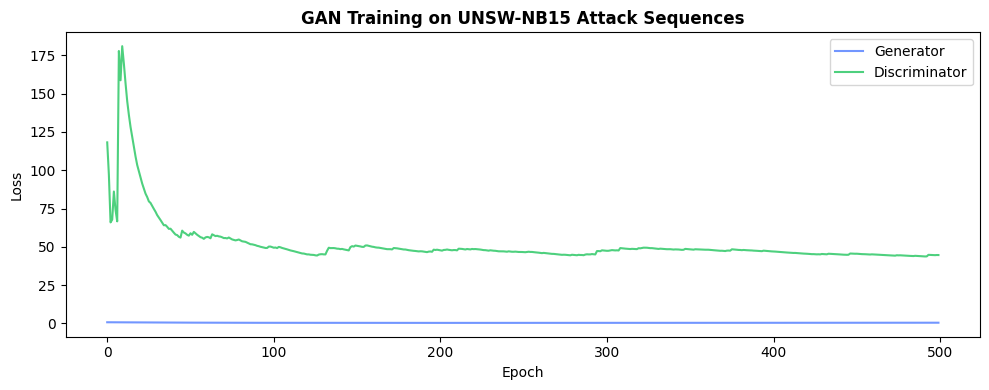

GAN generator saved.


In [11]:
LATENT_DIM = 64
SEQ_SHAPE  = (T, FEAT)

def build_generator(latent_dim, seq_shape):
    inp = keras.Input(shape=(latent_dim,))
    x   = layers.Dense(128, activation='relu')(inp)
    x   = layers.Dense(seq_shape[0] * 32, activation='relu')(x)
    x   = layers.Reshape((seq_shape[0], 32))(x)
    x   = layers.Conv1DTranspose(64, 3, activation='relu', padding='same')(x)
    x   = layers.Conv1DTranspose(seq_shape[1], 3, activation='tanh', padding='same')(x)
    return Model(inp, x, name='generator')

def build_discriminator(seq_shape):
    inp = keras.Input(shape=seq_shape)
    x   = layers.Conv1D(64, 3, padding='same')(inp)
    x   = layers.LeakyReLU(0.2)(x)
    x   = layers.Conv1D(128, 3, padding='same', strides=2)(x)
    x   = layers.LeakyReLU(0.2)(x)
    x   = layers.Flatten()(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    return Model(inp, out, name='discriminator')

generator     = build_generator(LATENT_DIM, SEQ_SHAPE)
discriminator = build_discriminator(SEQ_SHAPE)
discriminator.compile(optimizer=keras.optimizers.Adam(2e-4, beta_1=0.5),
                      loss='binary_crossentropy', metrics=['accuracy'])

discriminator.trainable = False
gan_inp  = keras.Input(shape=(LATENT_DIM,))
fake_seq = generator(gan_inp)
validity = discriminator(fake_seq)
gan = Model(gan_inp, validity, name='protector_gan')
gan.compile(optimizer=keras.optimizers.Adam(2e-4, beta_1=0.5),
            loss='binary_crossentropy')

# Train GAN only on attack sequences
X_attacks = X_seq_tr[y_seq_tr_b == 1]
print(f'GAN training on {len(X_attacks):,} attack sequences...')
g_losses, d_losses = [], []
BATCH = 64

for epoch in range(500):
    idx   = np.random.randint(0, len(X_attacks), BATCH)
    real  = X_attacks[idx].astype(np.float32)
    noise = np.random.normal(0, 1, (BATCH, LATENT_DIM)).astype(np.float32)
    fake  = generator.predict(noise, verbose=0)

    discriminator.trainable = True
    d_r = discriminator.train_on_batch(real, np.ones((BATCH, 1)) * 0.9)
    d_f = discriminator.train_on_batch(fake, np.zeros((BATCH, 1)))
    d_loss = 0.5 * (d_r[0] + d_f[0])

    discriminator.trainable = False
    noise2 = np.random.normal(0, 1, (BATCH, LATENT_DIM)).astype(np.float32)
    g_loss = gan.train_on_batch(noise2, np.ones((BATCH, 1)))

    g_losses.append(g_loss)
    d_losses.append(d_loss)
    if epoch % 100 == 0:
        print(f'  Epoch {epoch:3d} | D: {d_loss:.4f} | G: {g_loss:.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(g_losses, label='Generator',     color=PAL[0], alpha=0.8)
ax.plot(d_losses, label='Discriminator', color=PAL[1], alpha=0.8)
ax.set_title('GAN Training on UNSW-NB15 Attack Sequences', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend()
plt.tight_layout()
plt.savefig('models/gan_training.png', dpi=120)
plt.show()
generator.save('models/v2_gan_generator.keras')
print('GAN generator saved.')

Autoencoder training on 10,088 normal sequences...


Model: "protector_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 20, 42)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 20, 128)        │        87,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 20, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 20, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 20, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 20, 42)         │         5,418 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268,106 (1.02 MB)

 Trainable params: 268,106 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - loss: 46199076.0000 - val_loss: 43728272.0000
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 46196784.0000 - val_loss: 43727152.0000
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 46195636.0000 - val_loss: 43726144.0000
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 46194584.0000 - val_loss: 43725184.0000
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 46193568.0000 - val_loss: 43724248.0000
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 46192576.0000 - val_loss: 43723320.0000
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 46191600.0000 - val_loss: 43722412.0000
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 46190632.0000 - val_loss: 43721508.0000
Epoch 9/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 46189680.0000 - val_loss: 43720612.0000
Epoch 10/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 46188728.0000 - val_loss: 43719724.0000
Epoch 11/

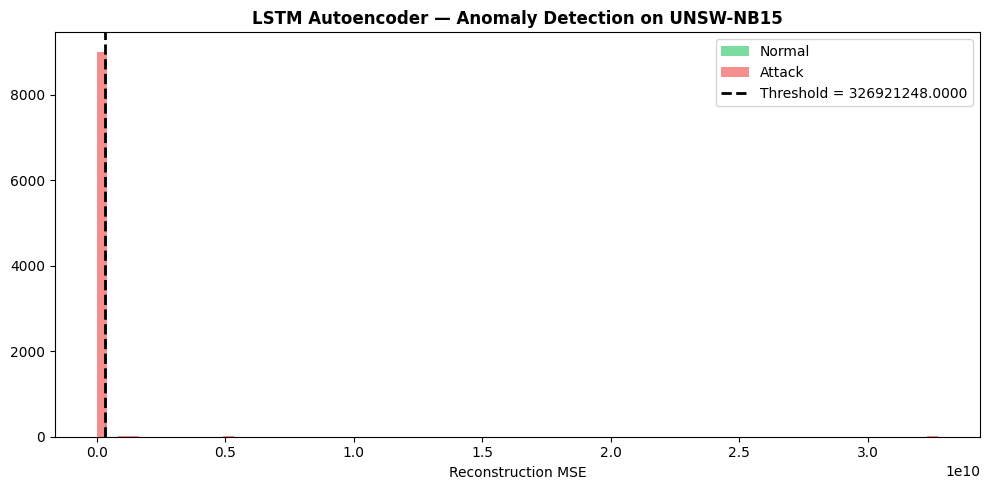

Autoencoder + threshold saved.


In [12]:
def build_autoencoder(T, FEAT, latent=32):
    inp = keras.Input(shape=(T, FEAT))
    # Encoder
    enc = layers.LSTM(128, return_sequences=True)(inp)
    enc = layers.LSTM(64,  return_sequences=False)(enc)
    enc = layers.Dense(latent, name='bottleneck')(enc)
    # Decoder
    dec = layers.RepeatVector(T)(enc)
    dec = layers.LSTM(64,  return_sequences=True)(dec)
    dec = layers.LSTM(128, return_sequences=True)(dec)
    out = layers.TimeDistributed(layers.Dense(FEAT))(dec)
    model = Model(inp, out, name='protector_autoencoder')
    model.compile(optimizer='adam', loss='mse')
    return model

# Train ONLY on normal (benign) sequences
X_normal_seq = X_seq_tr[y_seq_tr_b == 0]
X_tr_ae, X_va_ae = train_test_split(X_normal_seq, test_size=0.1, random_state=RANDOM)
print(f'Autoencoder training on {len(X_tr_ae):,} normal sequences...')

ae = build_autoencoder(T, FEAT, latent=32)
ae.summary()
ae.fit(X_tr_ae, X_tr_ae,
       epochs=50, batch_size=256,
       validation_data=(X_va_ae, X_va_ae),
       callbacks=[EarlyStopping(patience=8, restore_best_weights=True)],
       verbose=1)

# Compute reconstruction errors
recon_normal = np.mean((ae.predict(X_seq_te[y_seq_te_b==0], verbose=0)
                        - X_seq_te[y_seq_te_b==0])**2, axis=(1,2))
recon_attack = np.mean((ae.predict(X_seq_te[y_seq_te_b==1], verbose=0)
                        - X_seq_te[y_seq_te_b==1])**2, axis=(1,2))

threshold = float(np.percentile(recon_normal, 95))
det_ae    = float((recon_attack > threshold).mean())
fp_ae     = float((recon_normal > threshold).mean())

print(f'Autoencoder | Threshold:      {threshold:.6f}')
print(f'            | Detection rate: {det_ae:.4f}')
print(f'            | False positive: {fp_ae:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(recon_normal, bins=80, alpha=0.6, label='Normal', color=PAL[1])
ax.hist(recon_attack, bins=80, alpha=0.6, label='Attack', color=PAL[3])
ax.axvline(threshold, color='black', linestyle='--', lw=2,
           label=f'Threshold = {threshold:.4f}')
ax.set_xlabel('Reconstruction MSE')
ax.set_title('LSTM Autoencoder — Anomaly Detection on UNSW-NB15', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('models/autoencoder_anomaly.png', dpi=120)
plt.show()

ae.save('models/v2_autoencoder.keras')
with open('models/v2_ae_threshold.json', 'w') as f:
    json.dump({'threshold': threshold, 'det_rate': det_ae, 'fp_rate': fp_ae}, f)
print('Autoencoder + threshold saved.')

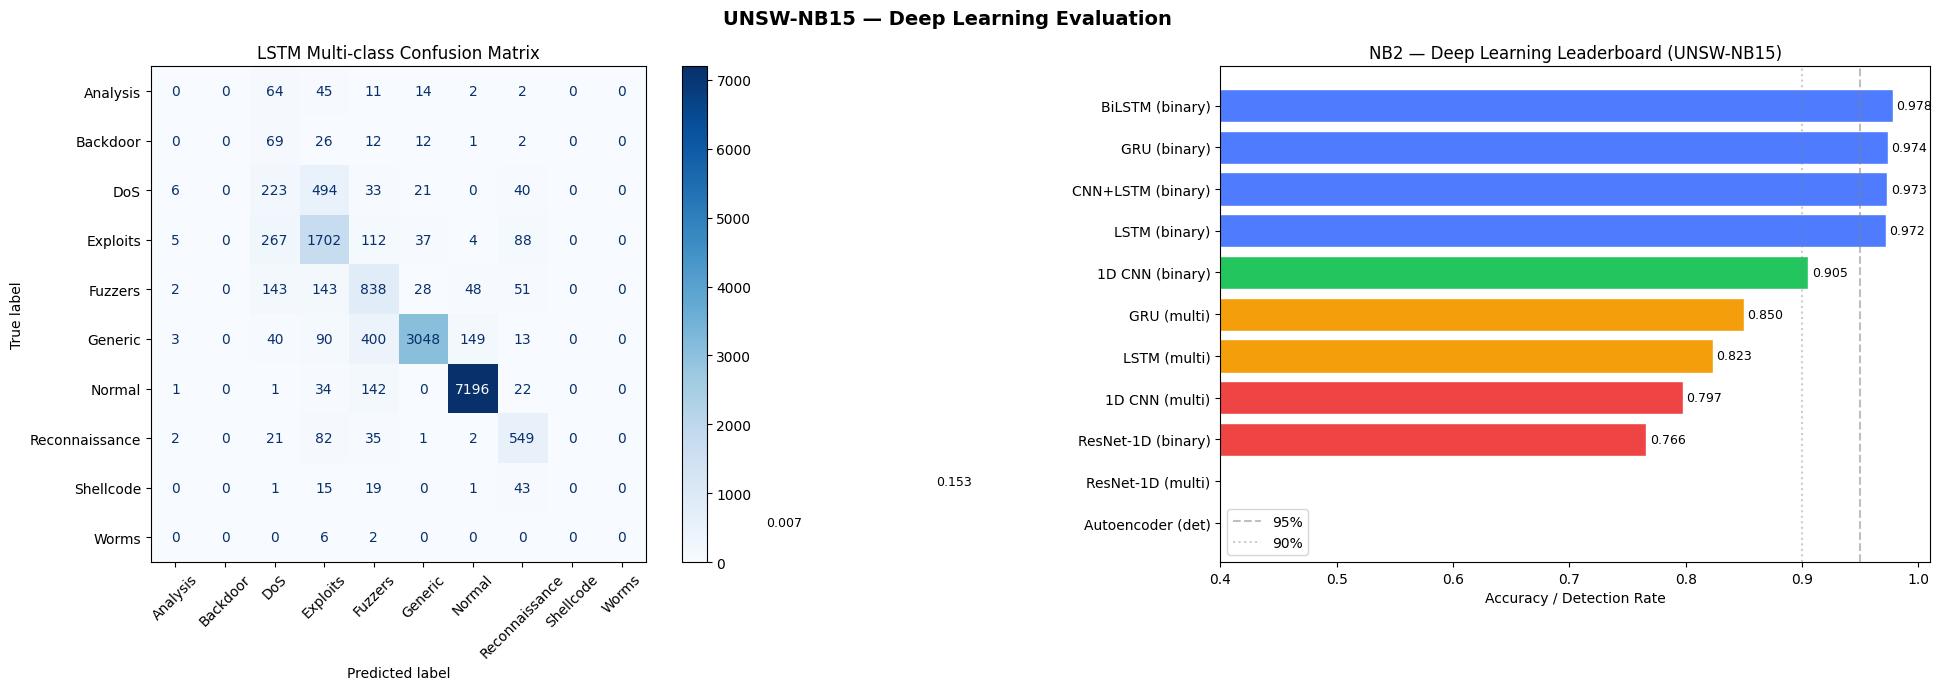


=== NB2 DEEP LEARNING LEADERBOARD ===
                       score
BiLSTM (binary)     0.978133
GRU (binary)        0.973699
CNN+LSTM (binary)   0.973152
LSTM (binary)       0.972241
1D CNN (binary)     0.905242
GRU (multi)         0.849845
LSTM (multi)        0.823422
1D CNN (multi)      0.797485
ResNet-1D (binary)  0.766082
ResNet-1D (multi)   0.152706
Autoencoder (det)   0.006617

Best model: BiLSTM (binary) (0.9781)


In [13]:
# Confusion matrix for best multi-class model (LSTM)
y_pred_lstm = np.argmax(lstm_m.predict(X_seq_te, verbose=0), axis=1)
cm   = confusion_matrix(y_seq_te_m, y_pred_lstm)
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('UNSW-NB15 — Deep Learning Evaluation', fontsize=14, fontweight='bold')

disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
disp.plot(ax=axes[0], colorbar=True, cmap='Blues', xticks_rotation=45)
axes[0].set_title(f'LSTM Multi-class Confusion Matrix')

# Leaderboard
dl_results = {
    '1D CNN (binary)'   : cnn_acc,
    '1D CNN (multi)'    : cnn_m_acc,
    'LSTM (binary)'     : lstm_acc,
    'LSTM (multi)'      : lstm_m_acc,
    'BiLSTM (binary)'   : bilstm_acc,
    'GRU (binary)'      : gru_acc,
    'GRU (multi)'       : gru_m_acc,
    'CNN+LSTM (binary)' : cnnlstm_acc,
    'ResNet-1D (binary)': resnet_acc,
    'ResNet-1D (multi)' : resnet_m_acc,
    'Autoencoder (det)' : det_ae,
}
df_res = pd.DataFrame({'score': dl_results}).sort_values('score', ascending=False)
colors = ['#4f7cff' if v > 0.95 else '#22c55e' if v > 0.90
          else '#f59e0b' if v > 0.80 else '#ef4444'
          for v in df_res['score']]
axes[1].barh(df_res.index[::-1], df_res['score'].values[::-1],
             color=colors[::-1], edgecolor='white')
axes[1].axvline(0.95, color='gray', linestyle='--', alpha=0.5, label='95%')
axes[1].axvline(0.90, color='gray', linestyle=':',  alpha=0.4, label='90%')
axes[1].set_xlabel('Accuracy / Detection Rate')
axes[1].set_title('NB2 — Deep Learning Leaderboard (UNSW-NB15)')
axes[1].set_xlim(0.4, 1.01)
axes[1].legend()
for i, v in enumerate(df_res['score'].values[::-1]):
    axes[1].text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('models/dl_leaderboard.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n=== NB2 DEEP LEARNING LEADERBOARD ===')
print(df_res.to_string())
print(f'\nBest model: {df_res["score"].idxmax()} ({df_res["score"].max():.4f})')

In [14]:
# Full classification report for best multi-class model
print('=== LSTM Multi-class Report ===')
print(classification_report(y_seq_te_m, y_pred_lstm,
                             target_names=CLASS_NAMES, zero_division=0))

# Save manifest
manifest = {
    'version'    : '2.0',
    'dataset'    : 'UNSW-NB15',
    'n_features' : FEAT,
    'features'   : ALL_FEATS,
    'T'          : T,
    'classes'    : CLASS_NAMES,
    'n_classes'  : N_CLASSES,
    'models'     : {
        'scaler'            : 'v2_scaler.pkl',
        'imputer'           : 'v2_imputer.pkl',
        'cat_encoders'      : 'v2_cat_encoders.pkl',
        'cnn_binary'        : 'v2_cnn.keras',
        'cnn_multi'         : 'v2_cnn_multi.keras',
        'lstm_binary'       : 'v2_lstm.keras',
        'lstm_multi'        : 'v2_lstm_multi.keras',
        'bilstm_binary'     : 'v2_bilstm.keras',
        'gru_binary'        : 'v2_gru.keras',
        'gru_multi'         : 'v2_gru_multi.keras',
        'cnn_lstm_binary'   : 'v2_cnn_lstm.keras',
        'resnet_binary'     : 'v2_resnet.keras',
        'resnet_multi'      : 'v2_resnet_multi.keras',
        'gan_generator'     : 'v2_gan_generator.keras',
        'autoencoder'       : 'v2_autoencoder.keras',
        'ae_threshold'      : 'v2_ae_threshold.json',
    },
    'leaderboard': dl_results
}
with open('models/v2_nb2_manifest.json', 'w') as f:
    json.dump(manifest, f, indent=2)

print('\nManifest saved to models/v2_nb2_manifest.json')
print('ZIP the models/ folder from Kaggle Output tab.')
print('Download and merge with NB1 models/ on your i3 machine.')

=== LSTM Multi-class Report ===
                precision    recall  f1-score   support

      Analysis       0.00      0.00      0.00       138
      Backdoor       0.00      0.00      0.00       122
           DoS       0.27      0.27      0.27       817
      Exploits       0.65      0.77      0.70      2215
       Fuzzers       0.52      0.67      0.59      1253
       Generic       0.96      0.81      0.88      3743
        Normal       0.97      0.97      0.97      7396
Reconnaissance       0.68      0.79      0.73       692
     Shellcode       0.00      0.00      0.00        79
         Worms       0.00      0.00      0.00         8

      accuracy                           0.82     16463
     macro avg       0.41      0.43      0.41     16463
  weighted avg       0.82      0.82      0.82     16463


Manifest saved to models/v2_nb2_manifest.json
ZIP the models/ folder from Kaggle Output tab.
Download and merge with NB1 models/ on your i3 machine.
